In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Ex 1: Binary Coding of Nominal Attribute

In [4]:
# Load the WH Report and display the first 3 rows
report_df = pd.read_csv('WH Report_preprocessed.csv')
report_df.head(3)

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
0,Afghanistan,Asia,2010,29185507.0,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
1,Afghanistan,Asia,2011,30117413.0,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
2,Afghanistan,Asia,2012,31161376.0,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268


In [6]:
# Set a boolean mask to be 2019 year only
BM = report_df.year == 2019

# Filter the report_df data using the BM of 2019
report2019_df = report_df[BM]

# Set the index to be the Name column
report2019_df.set_index('Name', inplace=True)

In [8]:
# Create a dataset of the dummy values for the Continent column
bc_Continent = pd.get_dummies(report2019_df.Continent)
bc_Continent.head(3)

,Africa,Antarctica,Asia,Europe,North America,Oceania,South America
Name,,,,,,,
Afghanistan,False,False,True,False,False,False,False
Albania,False,False,False,True,False,False,False
Algeria,True,False,False,False,False,False,False


In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Create the dimensions of the attributes to use in Kmeans
dimensions = ['Life_Ladder', 'Log_GDP_per_capita', 'Social_support',
              'Healthy_life_expectancy_at_birth', 'Freedom_to_make_life_choices',
              'Generosity', 'Perceptions_of_corruption', 'Positive_affect', 'Negative_affect']
Xs = report2019_df[dimensions]

# Perform normalization scaling using MinMaxScaler
Xs = MinMaxScaler().fit_transform(Xs)

# Create a dataframe of the scaled data using the dimensions as column names
# and the report2019_df index names as its index
X = pd.DataFrame(Xs, columns=dimensions, index=report2019_df.index)
X = X.join(bc_Continent/7)

# Create a KMeans model and fit the X data
kmeans = KMeans(n_clusters=3).fit(X)

# Print the country names (index values) for each cluster
for i in range(3):
    BM = kmeans.labels_== i
    print(f'Cluster {i}: {X[BM].index.values}')

Cluster 0: ['Albania' 'Argentina' 'Armenia' 'Azerbaijan' 'Belarus' 'Belgium'
 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Bulgaria' 'Chile'
 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Dominican Republic' 'Ecuador' 'El Salvador' 'Georgia' 'Greece'
 'Guatemala' 'Honduras' 'Hungary' 'Indonesia' 'Italy' 'Japan' 'Kazakhstan'
 'Kuwait' 'Latvia' 'Libya' 'Lithuania' 'Malaysia' 'Mexico' 'Moldova'
 'Mongolia' 'Montenegro' 'Nicaragua' 'Panama' 'Paraguay' 'Peru'
 'Philippines' 'Poland' 'Portugal' 'Romania' 'Saudi Arabia' 'Serbia'
 'Slovenia' 'South Africa' 'Spain' 'Sri Lanka' 'Tajikistan' 'Thailand'
 'Turkey' 'Turkmenistan' 'Ukraine' 'Vietnam']
Cluster 1: ['Afghanistan' 'Algeria' 'Bangladesh' 'Benin' 'Burkina Faso' 'Cambodia'
 'Cameroon' 'Chad' 'Ethiopia' 'Gabon' 'Ghana' 'Guinea' 'Haiti' 'India'
 'Iraq' 'Jordan' 'Kenya' 'Lebanon' 'Liberia' 'Madagascar' 'Malawi' 'Mali'
 'Mauritania' 'Morocco' 'Myanmar' 'Nepal' 'Niger' 'Nigeria' 'Pakistan'
 'Rwanda' 'Senegal' '

In [41]:
# Display the first 3 rows
X.head(3)

,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect,Africa,Antarctica,Asia,Europe,North America,Oceania,South America
Name,,,,,,,,,,,,,,,,
Afghanistan,0.000000,0.156130,0.000000,0.130282,0.015385,0.215709,0.956327,0.050967,1.000000,0.000000,0.0,0.142857,0.000000,0.0,0.0,0.0
Albania,0.484736,0.550619,0.473310,0.714789,0.670085,0.226260,0.945129,0.630931,0.373626,0.000000,0.0,0.000000,0.142857,0.0,0.0,0.0
Algeria,0.438483,0.506408,0.681495,0.612676,0.000000,0.348183,0.751400,0.462214,0.211538,0.142857,0.0,0.000000,0.000000,0.0,0.0,0.0


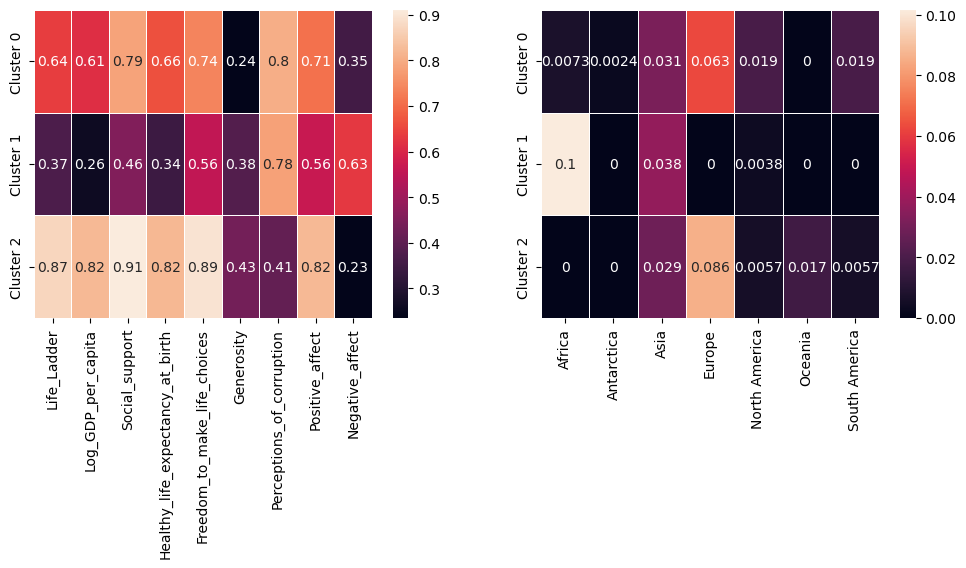

In [46]:
# Create 3 labels for the clusters
clusters = [f'Cluster {i}' for i in range(3)]

# Create an empty cluster centroid dataframe
Centroids = pd.DataFrame(0.0, 
                         index = clusters, 
                         columns = X.columns)

# Populate the centroid dataframe with the column mean values for each cluster
for i, clst in enumerate(clusters):
    BM = kmeans.labels_ == i
    Centroids.loc[clst] = X[BM].mean(axis=0)

# Plot the centroid cluster heatmaps for the dimensions
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.heatmap(Centroids[dimensions], linewidths=.5, 
            annot=True)

# Plot the centroid cluster heatmap for the continents
plt.subplot(1,2,2)
sns.heatmap(Centroids[bc_Continent.columns],
            linewidths=.5, annot=True)
plt.show()

#### Ex 3: Discretization of Numerical Attributes

In [55]:
# Load the adult data and display the first 3 rows
adult_df = pd.read_csv('adult.csv')
adult_df.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalGain,capitalLoss,hoursPerWeek,nativeCountry,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


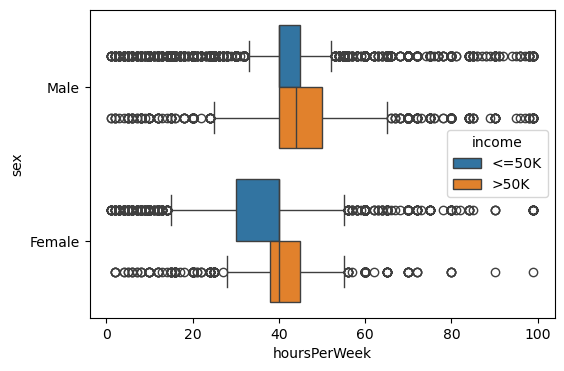

In [56]:
# Create a boxplot of hours worked per week by sex and income
plt.figure(figsize=(6,4))
sns.boxplot(data=adult_df, x='hoursPerWeek', y='sex', hue='income')
plt.show()

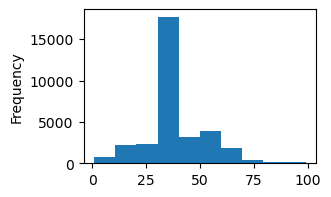

In [67]:
# Create histogram of hourse per week
plt.figure(figsize=(3,2))
adult_df.hoursPerWeek.plot.hist()
plt.show()

In [60]:
# Discretize the hoursPerWeek numerical attribute into 3 categorical values >40, 40, <40
adult_df['discretized_hoursPerWeek'] = adult_df.hoursPerWeek.apply(
    lambda x: '>40' if x>40 else ('40' if x==40 else '<40'))

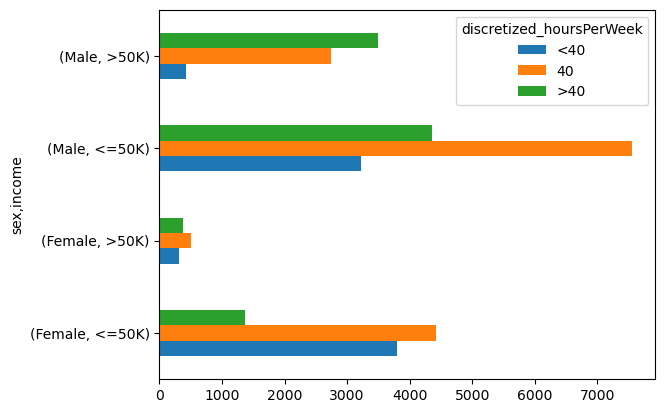

In [72]:
# Create a bar histogram plot of sex and income by hours per week
adult_df.groupby(['sex','income']).discretized_hoursPerWeek.value_counts().unstack()[['<40','40','>40']].plot.barh()
plt.show()

### Types of Discretization

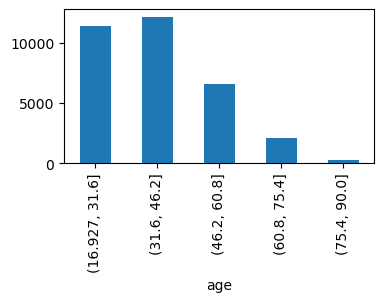

In [77]:
# Create a bar plot of 'equal width' columns using .cut() function
plt.figure(figsize=(4,2))
pd.cut(adult_df.age, bins=5).value_counts().sort_index().plot.bar()
plt.show()

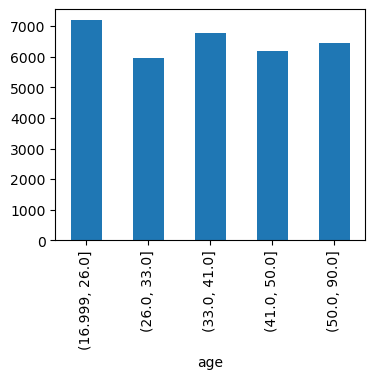

In [83]:
# Create a bar plot of 'equal frequency' columns using .qcut() function
plt.figure(figsize=(4,3))
pd.qcut(adult_df.age, q=5, 
        duplicates='drop').value_counts().sort_index().plot.bar()
plt.show()

#### Ex: Construct one transformed attribute from two attributes

In [89]:
# load the Gender height weight data and display the first 3 rows
person_df = pd.read_csv('500_Person_Gender_Height_Weight_Index.csv')
person_df.head(3)


,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4


In [90]:
# Change the Index column values form numerical to categorical values
person_df.Index = person_df.Index.replace({0:'Extremely Weak', 1: 'Weak',2: 'Normal',3:'Overweight', 4:'Obesity',5:'Extreme Obesity'})

# Rename the column Index to Condition
person_df.columns = ['Gender', 'Height', 'Weight', 'Condition']

# Display the first 3 rows
person_df.head(3)


,Gender,Height,Weight,Condition
0,Male,174,96,Obesity
1,Male,189,87,Normal
2,Female,185,110,Obesity


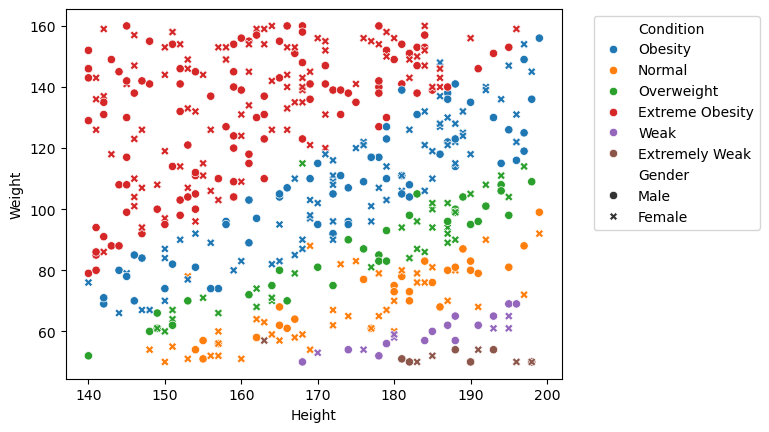

In [93]:
# Create scatterplot of the data using both hue and style with attributes
sns.scatterplot(data = person_df, x='Height', y='Weight',
                hue = 'Condition', style = 'Gender')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

In [95]:
# Create a BMI attribue from the height and weight attributes
person_df['BMI'] = person_df.apply(
    lambda x: x.Weight / ((x.Height/100)**2), axis=1)
person_df.head(3)

,Gender,Height,Weight,Condition,BMI
0,Male,174,96,Obesity,31.708284
1,Male,189,87,Normal,24.355421
2,Female,185,110,Obesity,32.140248


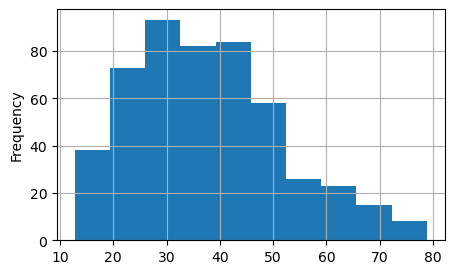

In [108]:
# Create histogram of BMI attribute
plt.figure(figsize=(5,3))
person_df.BMI.plot.hist()
plt.grid()
plt.show()

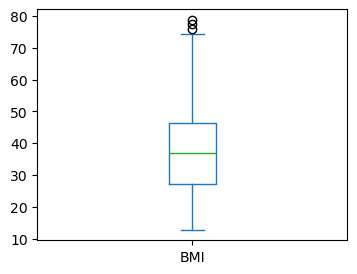

In [109]:
# Create boxplot of BMI attribute
plt.figure(figsize=(4,3))
person_df.BMI.plot.box()
plt.show()

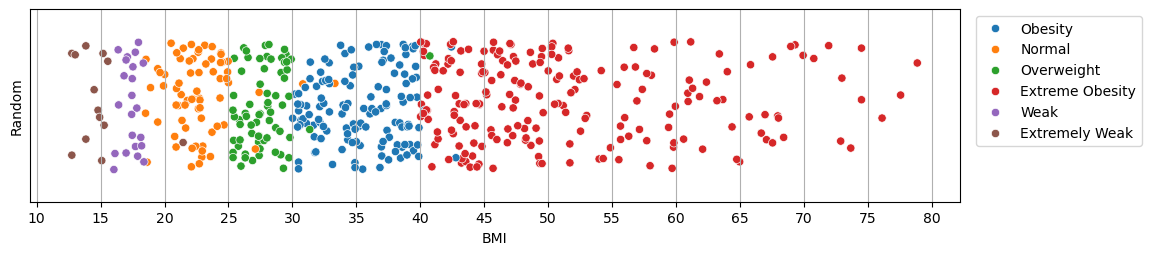

In [111]:
# Create new field called Random to separate out the data more visually. 
# Has no other value than for separate points out more visually
person_df['Random'] = np.random.random(len(person_df))

# Create a scatterplot of the BMI values by condition
plt.figure(figsize=(12,2.5))
sns.scatterplot(data = person_df, x='BMI', y='Random', hue='Condition')
plt.ylim([-0.25,1.25])
plt.xticks(np.linspace(10,80,15))
plt.yticks([])
plt.grid()
plt.legend(bbox_to_anchor=(1.01, 1))
plt.show()

### Log Transformation

In [113]:
# Load country GDP data, set the index value to the country name and display the first 3 rows
country_df = pd.read_csv('GDP 2019 2020.csv')
country_df.set_index('Country Name', inplace=True)
country_df.head(3)

,Country Code,2019,2020
Country Name,,,
Afghanistan,AFG,1.929110e+10,1.980707e+10
Angola,AGO,8.941719e+10,6.230691e+10
Albania,ALB,1.528661e+10,1.479962e+10


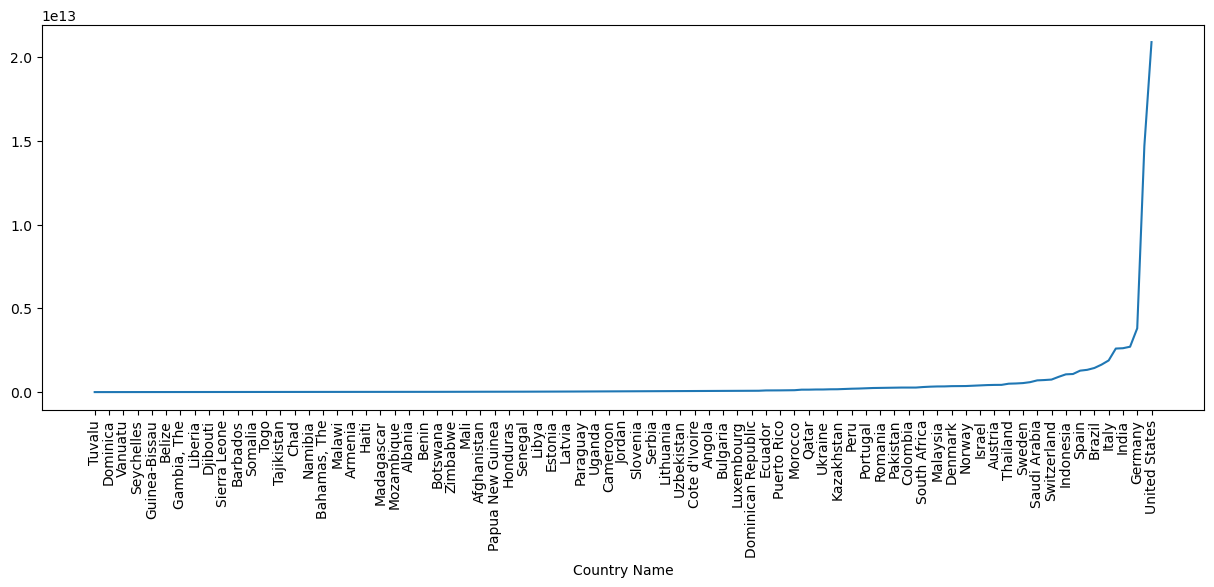

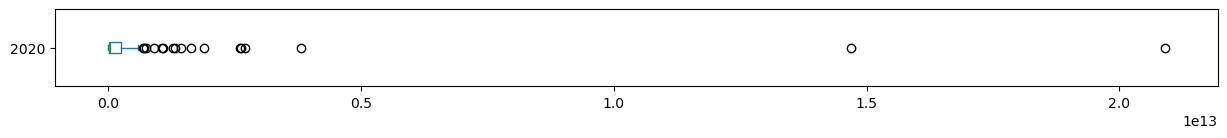

In [118]:
# Plot the original 2020 data
intervals = [i*2 for i in range(75)]

wdf = country_df[['2019','2020']].sort_values('2020')
wdf['2020'].plot(figsize=(15,5))

plt.xticks(intervals,wdf.iloc[intervals].index,rotation=90)
plt.show()

wdf['2020'].plot.box(vert=False,figsize = (15,1))
plt.show()

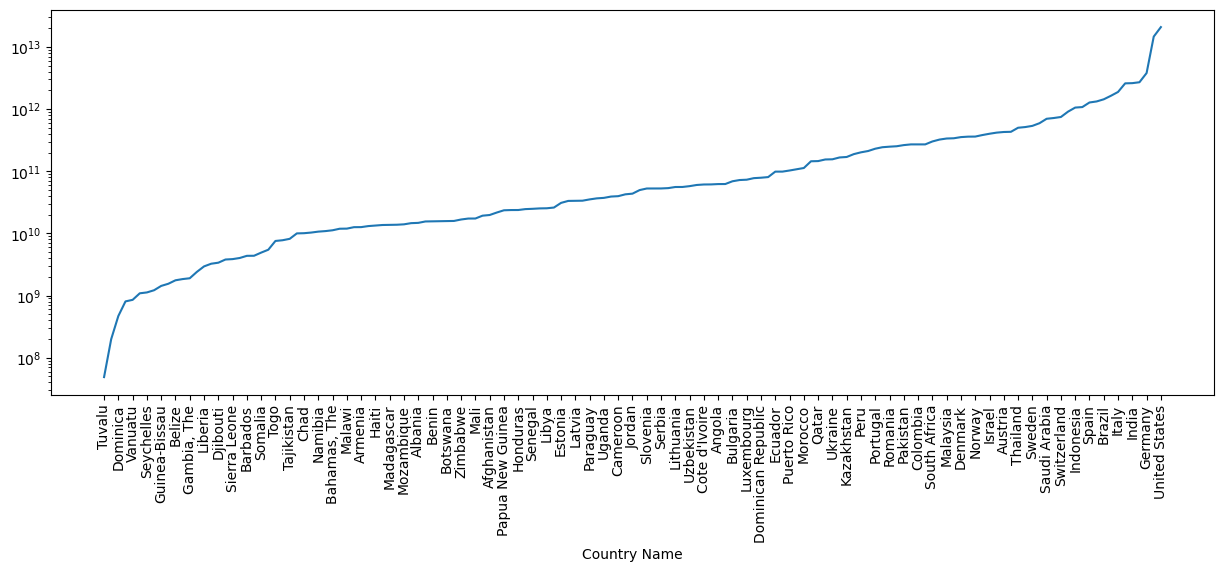

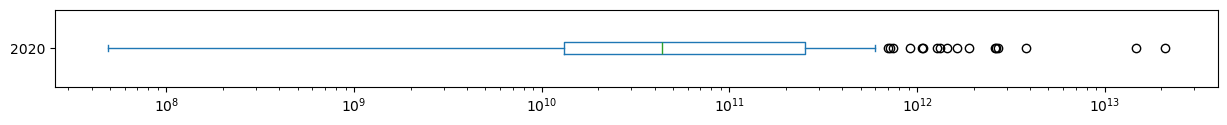

In [120]:
# Plot the 2020 log transformed data
intervals = [i*2 for i in range(75)]

wdf = country_df[['2019','2020']].sort_values('2020')
wdf['2020'].plot(figsize=(15,5),logy=True)

plt.xticks(intervals,wdf.iloc[intervals].index,rotation=90)
plt.show()

wdf['2020'].plot.box(vert=False,figsize = (15,1),logx=True)
plt.show()

#### Implementaion of log transformation

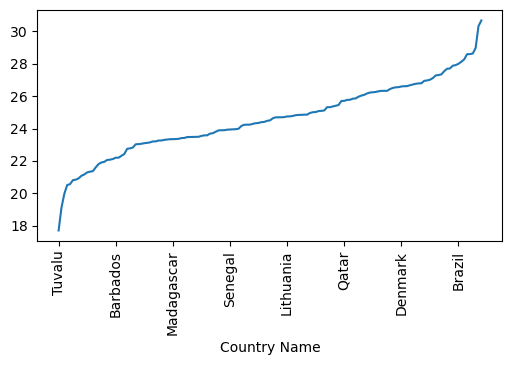

In [124]:
# Create a new column of log transformation of the 2020 column
country_df['log_2020']= np.log(country_df['2020'])

# Create a line plot of the log_2020 attribute
plt.figure(figsize=(6,3))
country_df.log_2020.sort_values().plot()
plt.xticks(rotation=90)
plt.show()

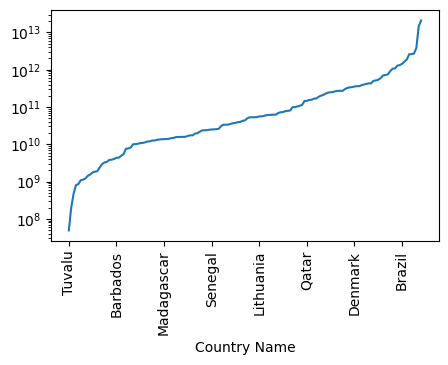

In [131]:
# Create a line plot of the log_2020 attribute
plt.figure(figsize=(5,3))
country_df['2020'].sort_values().plot(logy=True) # Put in brackets because it is a number name
plt.xticks(rotation=90)
plt.show()

### Smoothing

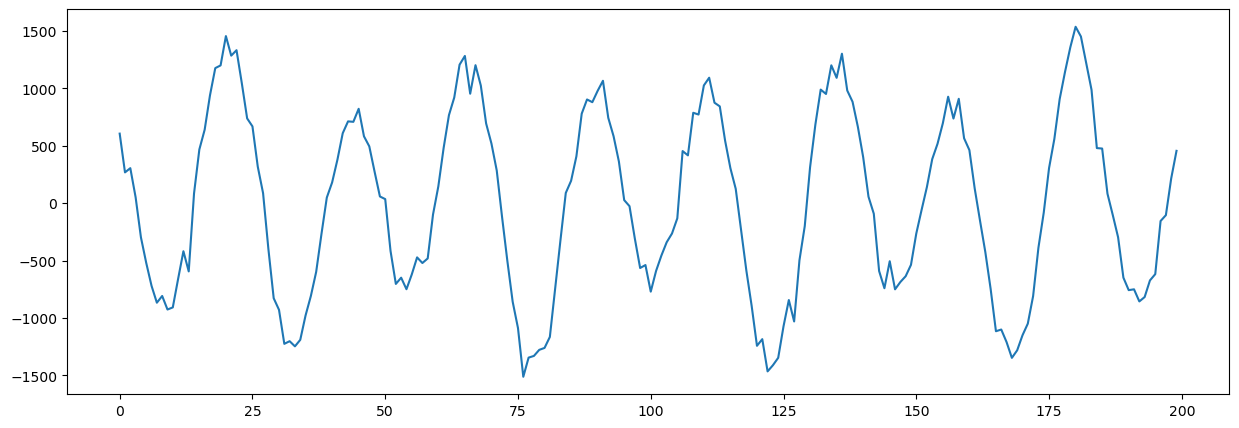

In [133]:
# Load noise data and plot the signal
signal_df = pd.read_csv('Noise_data.csv')
signal_df.drop(columns='t',inplace=True)
signal_df.Signal.plot(figsize=(15,5))
plt.show()

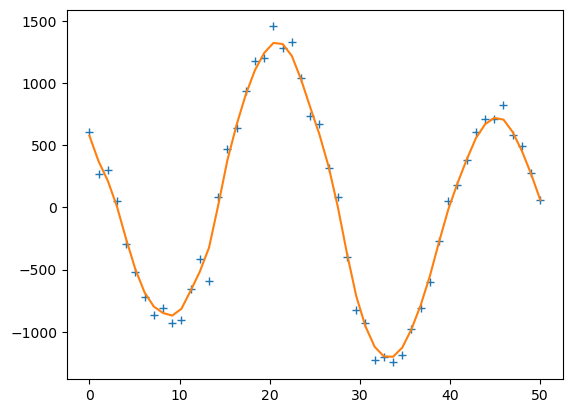

In [139]:
# Use KernelReg to smooth the Signal attribute
from statsmodels.nonparametric.kernel_regression import KernelReg
x = np.linspace(0,50,50)
y = signal_df.Signal.iloc[:50]
plt.plot(x, y, '+')

kr = KernelReg(y,x,'c')
y_pred, y_std = kr.fit(x)

plt.plot(x, y_pred)
plt.show()

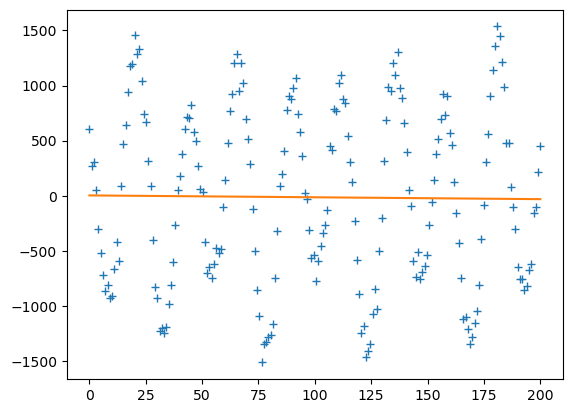

In [140]:
# Use KernelReg to smooth the Signal attribute like the code above
# In this instance, there are more data points causing the KernelReg to fail
# as noted by the straight line
x = np.linspace(0,200,200)
y = signal_df.Signal
plt.plot(x, y, '+')

kr = KernelReg(y,x,'c')
y_pred, y_std = kr.fit(x)

plt.plot(x, y_pred)
plt.show()

### Rolling Data Smoothing

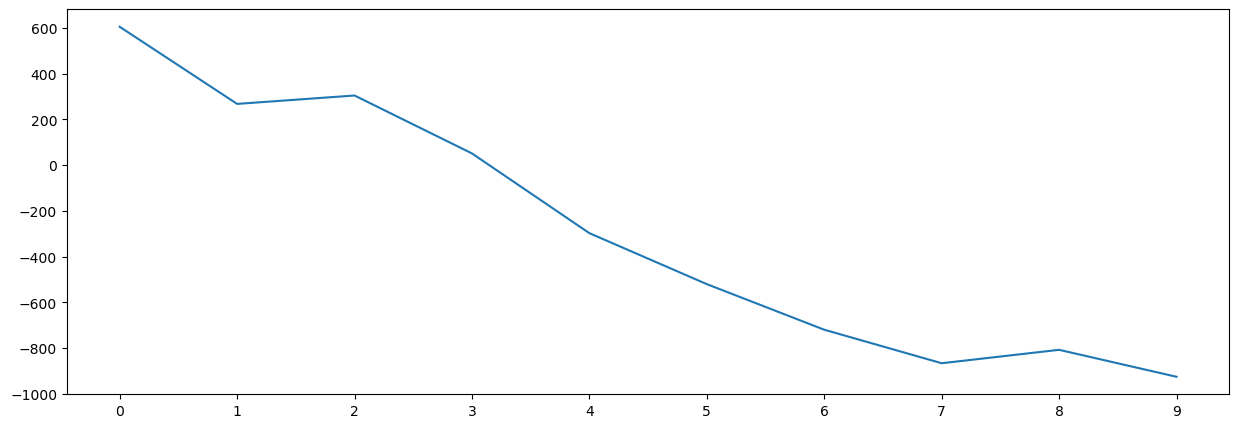

In [142]:
# Plot the first 10 data points of the Signal attribute
signal_df.Signal.iloc[:10].plot(figsize=(15,5))

plt.xticks([i for i in range(10)])
plt.show()

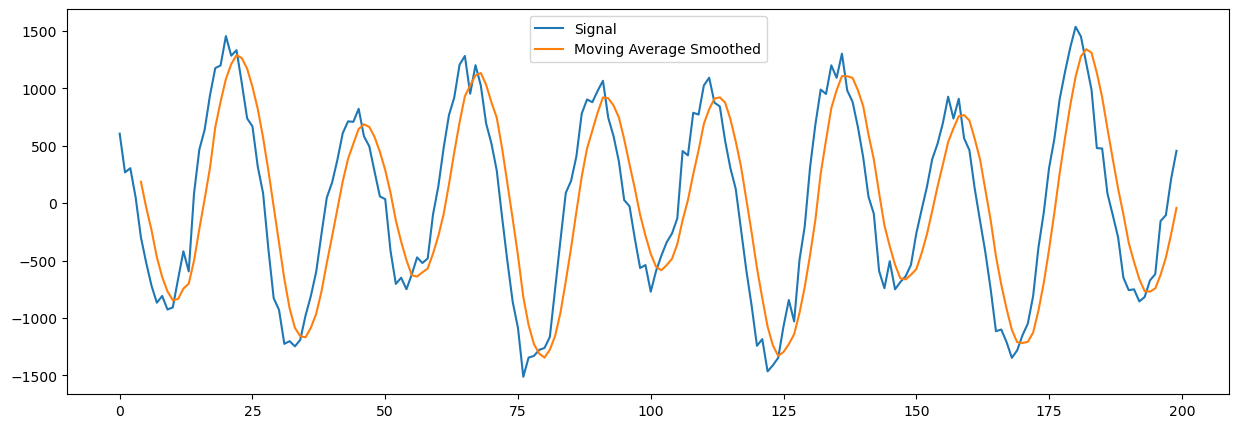

In [145]:
# PLot the signal data
signal_df.Signal.plot(figsize=(15,5), label='Signal')

# Plot a 5 day moving average of signal data
signal_df.Signal.rolling(window=5).mean().plot(label='Moving Average Smoothed')
plt.legend()
plt.show()

In [146]:
# Show the first 10 rows of the moving average data next to the signal data
pd.DataFrame({'Signal':signal_df.Signal.iloc[:50],
              'Moving Average Smoothed':signal_df.Signal.iloc[:50].rolling(
                  window=5).mean()}).head(10)

,Signal,Moving Average Smoothed
0,605.340308,NaN
1,267.958658,NaN
2,304.652019,NaN
3,51.297364,NaN
4,-297.546288,186.340412
5,-520.492600,-38.826169
6,-719.919832,-236.401867
7,-866.546219,-470.641515
8,-807.907263,-642.482441
9,-925.817440,-768.136671


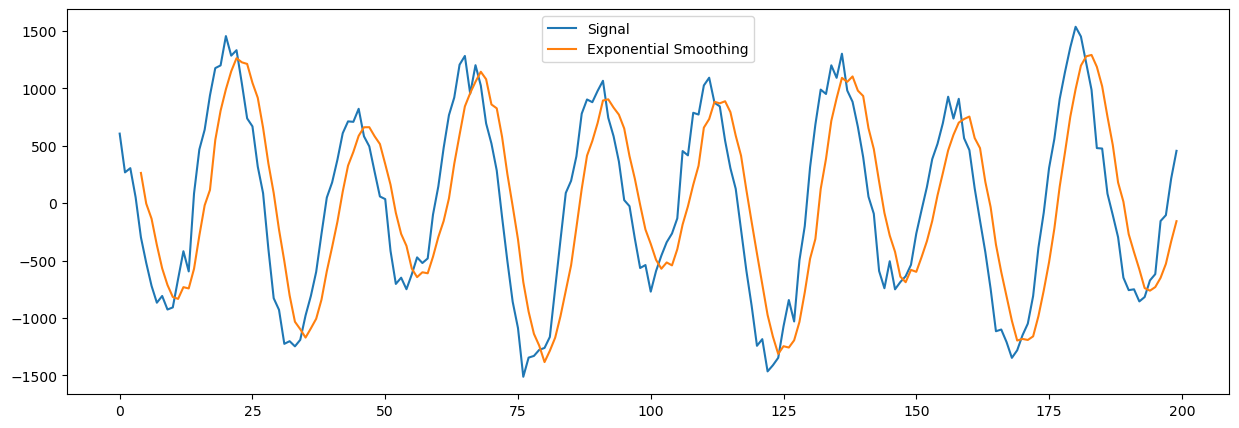

In [148]:
# Create function for exponential smoothing
def ExpSmoothing(v):
    a=0.2
    yhat=v.iloc[0]
    for i in range(len(v)):
        yhat = a*v.iloc[i] + (1-a)*yhat
    return yhat

# Plot the original signal data
signal_df.Signal.plot(figsize=(15,5), label='Signal')

# Plot the exponential smoothing data
signal_df.Signal.rolling(window=5).apply(
    ExpSmoothing).plot(label = 'Exponential Smoothing')
plt.legend()
plt.show()

### Binning

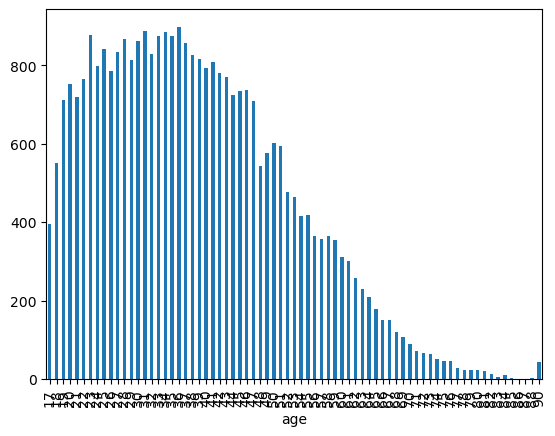

In [150]:
adult_df['age'].value_counts().sort_index().plot.bar()
plt.show()

<Axes: ylabel='Frequency'>

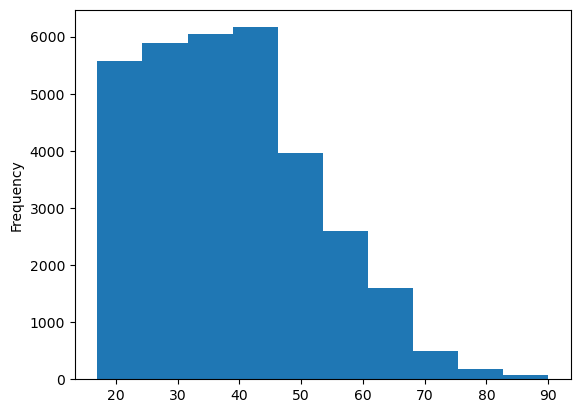

In [153]:
adult_df['age'].plot.hist()

<Axes: xlabel='age_binned'>

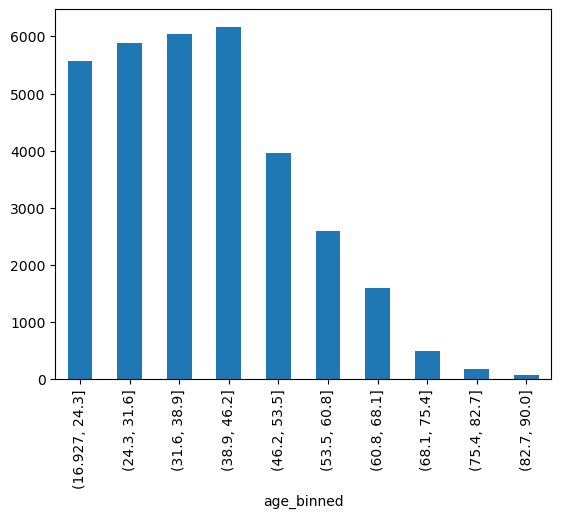

In [155]:
# Binn the age into 10 buckets
adult_df['age_binned']=pd.cut(adult_df.age,10)
adult_df.age_binned.value_counts().sort_index().plot.bar()

In [156]:
adult_df.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalGain,capitalLoss,hoursPerWeek,nativeCountry,income,discretized_hoursPerWeek,age_binned
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,40,"(38.9, 46.2]"
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,<40,"(46.2, 53.5]"
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,40,"(31.6, 38.9]"
